Creates Figure 10 of the main paper

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models used and their start years

models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat


In [3]:
#load data

data_z500_npac_all_E = np.ma.masked_equal(np.zeros([8,4,72,144]),0)
data_z500_npac_all_L = np.ma.masked_equal(np.zeros([8,4,72,144]),0)


outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    eof_T='_F6data_pr'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)
    
        
   # if ii==0:
    #    data_z500_npac=data_z500_npac*1000  
     
    for i in range(4): 
        data_z500_npac_all_E[ii,i,...]=data_z500_npac[i,0+offset:10+offset,...].mean(axis=0)
        data_z500_npac_all_L[ii,i,...]=data_z500_npac[i,164+offset:174+offset,...].mean(axis=0)


        
        
        

In [4]:
data_z500_npac_all_E_M=data_z500_npac_all_E.mean(axis=0)
data_z500_npac_all_L_M=data_z500_npac_all_L.mean(axis=0)




In [5]:
data_z500_npac_all_E_S=data_z500_npac_all_E.std(axis=0)

npac=data_z500_npac_all_L-data_z500_npac_all_E

data_z500_npac_all_EL_S=npac.std(axis=0)




In [6]:
## add the full with tpac data

dataF_z500_npac_all_E = np.ma.masked_equal(np.zeros([8,4,72,144]),0)
dataF_z500_npac_all_L = np.ma.masked_equal(np.zeros([8,4,72,144]),0)



outputdir_figD='/glade/work/nmaher/SEOF_output/Fig_data/'


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    eof_T='_F1bdata_zgNPac'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_npac = np.ma.MaskedArray(**npz)*86400
        
    if ii==0:
        data_z500_npac=data_z500_npac*1000
    
    
    eof_T='_F1bdata_zgNAt'
    with np.load(outputdir_figD+model+eof_T+'.npz') as npz:
        data_z500_nat = np.ma.MaskedArray(**npz)*86400
        
    if ii==0:
        data_z500_nat=data_z500_nat*1000
    
     
    for i in range(3): 
        dataF_z500_npac_all_E[ii,i,...]=data_z500_npac[i,0+offset:10+offset,...].mean(axis=0)
        dataF_z500_npac_all_L[ii,i,...]=data_z500_npac[i,164+offset:174+offset,...].mean(axis=0)


        
    for i in range(1): 
        dataF_z500_npac_all_E[ii,i+3,...]=data_z500_nat[i,0+offset:10+offset,...].mean(axis=0)
        dataF_z500_npac_all_L[ii,i+3,...]=data_z500_nat[i,164+offset:174+offset,...].mean(axis=0)
        
        
dataF_z500_npac_all_E_M=dataF_z500_npac_all_E.mean(axis=0)
dataF_z500_npac_all_L_M=dataF_z500_npac_all_L.mean(axis=0)

dataF_z500_npac_all_E_S=dataF_z500_npac_all_E.std(axis=0)


npacF=dataF_z500_npac_all_L-dataF_z500_npac_all_E

dataF_z500_npac_all_EL_S=npacF.std(axis=0)

In [7]:
#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat

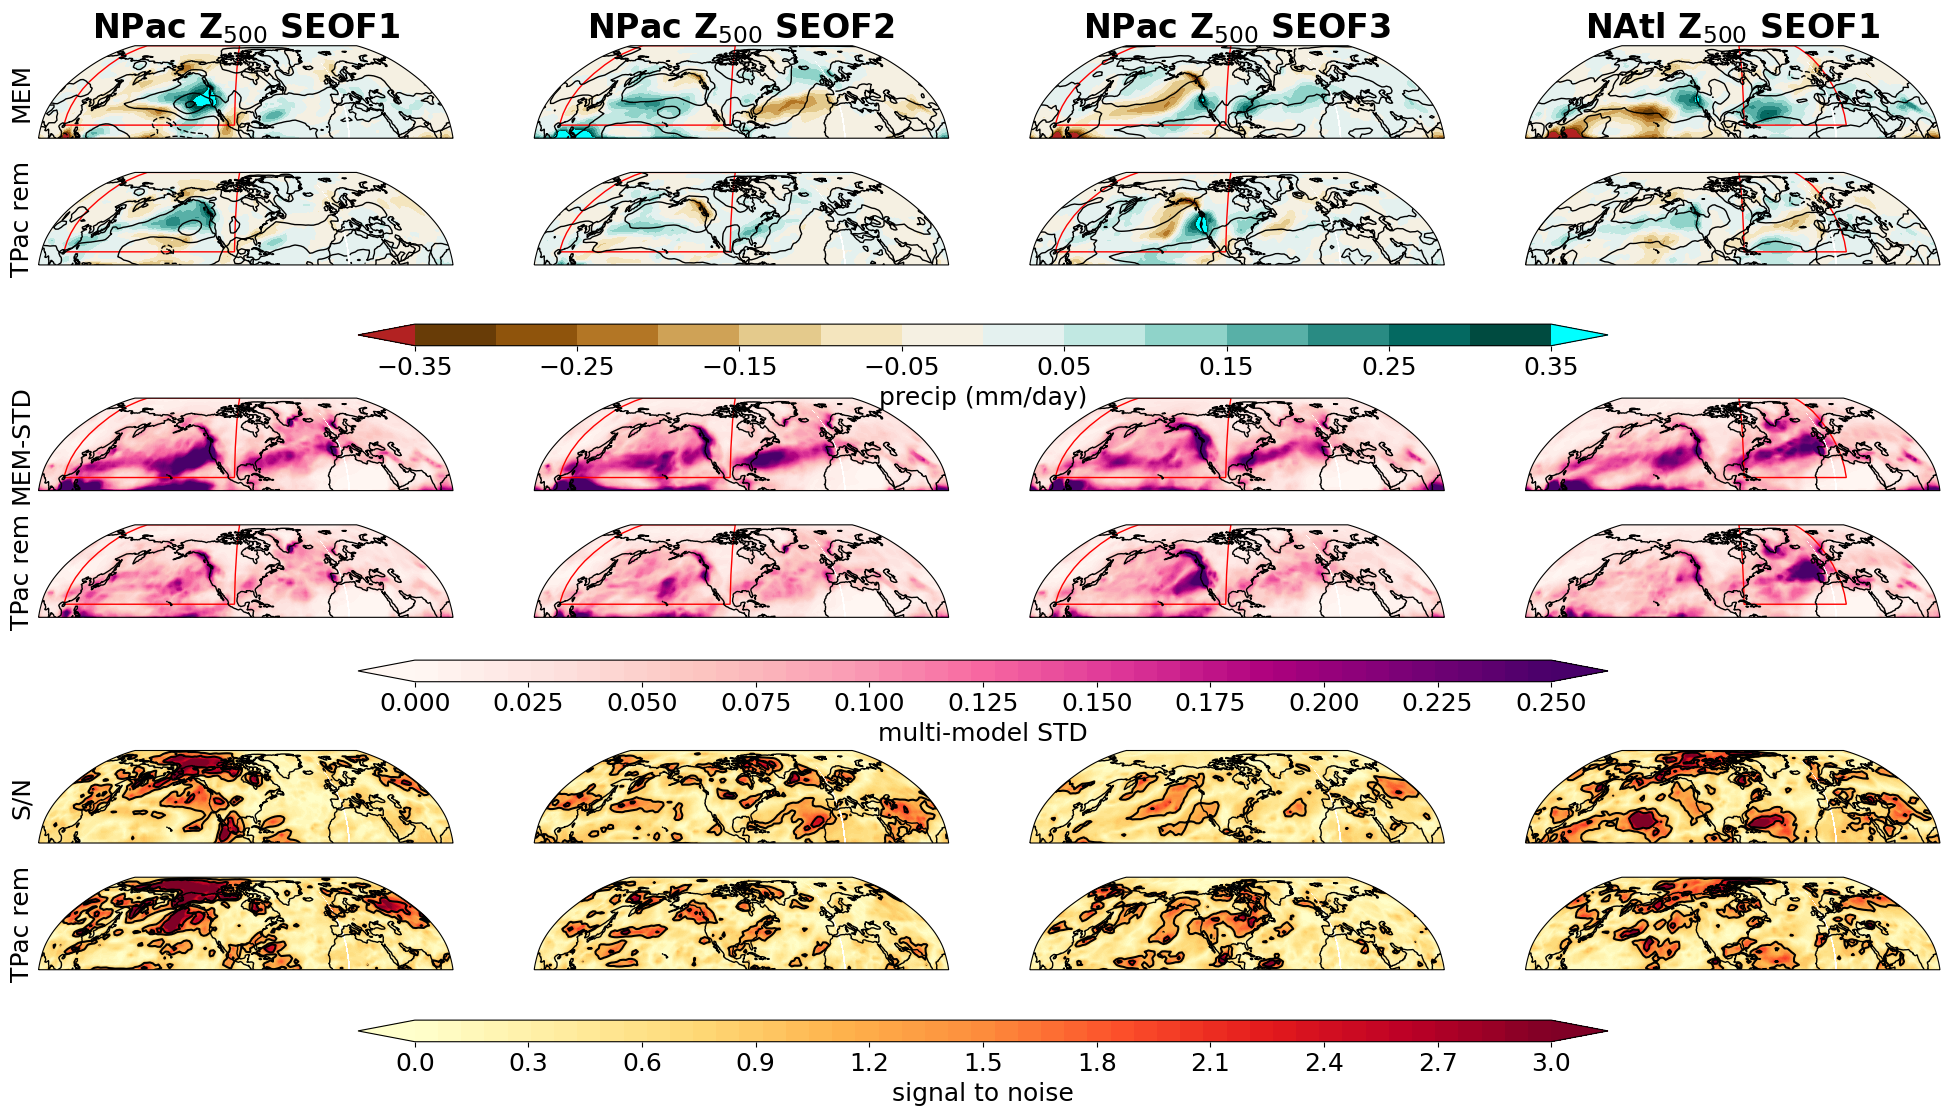

In [11]:
#plot data
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(25, 12))

# 8 rows: 2 + spacer + 2 + spacer + 2
gs = gridspec.GridSpec(
    8, 4,
    height_ratios=[1, 1, 0.7, 1, 1, 0.7, 1, 1],
    hspace=0.4, wspace=0.1,
    figure=fig
)

# Make a 6x4 array to store axes (6 plotting rows total)
axs = np.empty((6, 4), dtype=object)

# Fill the first set (rows 0–1 in GridSpec)
for i in range(2):
    for j in range(4):
        axs[i, j] = fig.add_subplot(gs[i, j],
                                    projection=ccrs.Robinson(central_longitude=270))

# Fill the second set (rows 3–4 in GridSpec)
for i in range(2, 4):
    gs_row = i + 1  # skip first spacer at row index 2
    for j in range(4):
        axs[i, j] = fig.add_subplot(gs[gs_row, j],
                                    projection=ccrs.Robinson(central_longitude=270))

# Fill the third set (rows 6–7 in GridSpec)
for i in range(4, 6):
    gs_row = i + 2  # skip two spacers (row indices 2 and 5)
    for j in range(4):
        axs[i, j] = fig.add_subplot(gs[gs_row, j],
                                    projection=ccrs.Robinson(central_longitude=270))

# Now you can use axs[row, col] as before
#cplt = axs[0, 0].contourf(...)  # works!

#fig,axs = PP.subplots(4,4,figsize=(35,15), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})
e=[-180, 180,10,90]


clevels = np.arange(-1,1.5,0.5)
levels = np.arange(-0.35,0.4,0.05)  # for precip
cmap = copy.deepcopy(mpl.cm.BrBG)
cmap.set_over('cyan')
cmap.set_under('firebrick')
clevels = np.arange(-1,1.5,0.5)


slevels2 = np.linspace(0,0.25)
cmap3=copy.deepcopy(mpl.cm.RdPu)#copy.deepcopy(mpl.cm.plasma)

slevels = np.linspace(0,3)
cmap2=copy.deepcopy(mpl.cm.YlOrRd)


clon=lon

cplt = axs[0,0].contourf(clon,lat,dataF_z500_npac_all_L_M[0,...]-dataF_z500_npac_all_E_M[0,...], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[0,0].contour(clon,lat,dataF_z500_npac_all_E_M[0,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[0,0].coastlines()
axs[0,0].set_ylim(-30,90)
cplt = axs[2,0].contourf(clon,lat,dataF_z500_npac_all_EL_S[0,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[2,0].coastlines()
axs[2,0].set_ylim(-30,90)
cplt = axs[4,0].contourf(clon,lat,np.abs((dataF_z500_npac_all_L_M[0,...]-dataF_z500_npac_all_E_M[0,...])/dataF_z500_npac_all_EL_S[0,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[4, 0].contour(clon, lat, np.abs((dataF_z500_npac_all_L_M[0,...]-dataF_z500_npac_all_E_M[0,...])/dataF_z500_npac_all_EL_S[0,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())


axs[4,0].coastlines()
axs[4,0].set_ylim(-30,90)
#diffs

cplt = axs[1,0].contourf(clon,lat,(data_z500_npac_all_L_M[0,...]-data_z500_npac_all_E_M[0,...]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[1,0].contour(clon,lat,data_z500_npac_all_E_M[0,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   
axs[1,0].coastlines()
axs[1,0].set_ylim(-30,90)
cplt = axs[3,0].contourf(clon,lat,data_z500_npac_all_EL_S[0,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[3,0].coastlines()
axs[3,0].set_ylim(-30,90)
cplt = axs[5,0].contourf(clon,lat,np.abs((data_z500_npac_all_L_M[0,...]-data_z500_npac_all_E_M[0,...])/data_z500_npac_all_EL_S[0,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[5, 0].contour(clon, lat, np.abs((data_z500_npac_all_L_M[0,...]-data_z500_npac_all_E_M[0,...])/data_z500_npac_all_EL_S[0,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[5,0].coastlines()
axs[5,0].set_ylim(-30,90)


cplt = axs[0,1].contourf(clon,lat,dataF_z500_npac_all_L_M[1,...]-dataF_z500_npac_all_E_M[1,...], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[0,1].contour(clon,lat,dataF_z500_npac_all_E_M[1,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   
axs[0,1].coastlines()
axs[0,1].set_ylim(-30,90)
cplt = axs[2,1].contourf(clon,lat,dataF_z500_npac_all_EL_S[1,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[2,1].coastlines()
axs[2,1].set_ylim(-30,90)
cplt = axs[4,1].contourf(clon,lat,np.abs((dataF_z500_npac_all_L_M[1,...]-dataF_z500_npac_all_E_M[1,...])/dataF_z500_npac_all_EL_S[1,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[4,1].contour(clon, lat, np.abs((dataF_z500_npac_all_L_M[1,...]-dataF_z500_npac_all_E_M[1,...])/dataF_z500_npac_all_EL_S[1,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[4,1].coastlines()
axs[4,1].set_ylim(-30,90)
#diffs

cplt = axs[1,1].contourf(clon,lat,(data_z500_npac_all_L_M[1,...]-data_z500_npac_all_E_M[1,...]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[1,1].contour(clon,lat,data_z500_npac_all_E_M[1,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[1,1].coastlines()
axs[1,1].set_ylim(-30,90)
cplt = axs[3,1].contourf(clon,lat,data_z500_npac_all_EL_S[1,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[3,1].coastlines()
axs[3,1].set_ylim(-30,90)
cplt = axs[5,1].contourf(clon,lat,np.abs((data_z500_npac_all_L_M[1,...]-data_z500_npac_all_E_M[1,...])/data_z500_npac_all_EL_S[1,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[5,1].contour(clon, lat, np.abs((data_z500_npac_all_L_M[1,...]-data_z500_npac_all_E_M[1,...])/data_z500_npac_all_EL_S[1,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[5,1].coastlines()
axs[5,1].set_ylim(-30,90)

cplt = axs[0,2].contourf(clon,lat,dataF_z500_npac_all_L_M[2,...]-dataF_z500_npac_all_E_M[2,...], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[0,2].contour(clon,lat,dataF_z500_npac_all_E_M[2,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[0,2].coastlines()
axs[0,2].set_ylim(-30,90)
cplt = axs[2,2].contourf(clon,lat,dataF_z500_npac_all_EL_S[2,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[2,2].coastlines()
axs[2,2].set_ylim(-30,90)
cplt = axs[4,2].contourf(clon,lat,np.abs((dataF_z500_npac_all_L_M[2,...]-dataF_z500_npac_all_E_M[2,...])/dataF_z500_npac_all_EL_S[2,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[4,2].contour(clon, lat, np.abs((dataF_z500_npac_all_L_M[2,...]-dataF_z500_npac_all_E_M[2,...])/dataF_z500_npac_all_EL_S[2,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[4,2].coastlines()
axs[4,2].set_ylim(-30,90)
#diffs

cplt = axs[1,2].contourf(clon,lat,(data_z500_npac_all_L_M[2,...]-data_z500_npac_all_E_M[2,...]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[1,2].contour(clon,lat,data_z500_npac_all_E_M[2,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[1,2].coastlines()
axs[1,2].set_ylim(-30,90)
cplt = axs[3,2].contourf(clon,lat,data_z500_npac_all_EL_S[2,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[3,2].coastlines()
axs[3,2].set_ylim(-30,90)
cplt = axs[5,2].contourf(clon,lat,np.abs((data_z500_npac_all_L_M[2,...]-data_z500_npac_all_E_M[2,...])/data_z500_npac_all_EL_S[2,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[5,2].contour(clon, lat, np.abs((data_z500_npac_all_L_M[2,...]-data_z500_npac_all_E_M[2,...])/data_z500_npac_all_EL_S[2,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[5,2].coastlines()
axs[5,2].set_ylim(-30,90)

cplt = axs[0,3].contourf(clon,lat,dataF_z500_npac_all_L_M[3,...]-dataF_z500_npac_all_E_M[3,...], transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[0,3].contour(clon,lat,dataF_z500_npac_all_E_M[3,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[0,3].coastlines()
axs[0,3].set_ylim(-30,90)

cticks = np.linspace(-1,1,21)
cbar_ax = fig.add_axes([0.26, 0.63, 0.5, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=levels[::2])
cbar.set_label('precip (mm/day)',fontsize=18)
cbar.ax.tick_params(labelsize=18)


#diffs
cplt = axs[1,3].contourf(clon,lat,(data_z500_npac_all_L_M[3,...]-data_z500_npac_all_E_M[3,...]), transform=ccrs.PlateCarree(), levels=levels, cmap=cmap, extend='both')   
cpltc = axs[1,3].contour(clon,lat,data_z500_npac_all_E_M[3,...], transform=ccrs.PlateCarree(), levels=clevels,  colors='k', linewidths=1.0, extend='both')   

axs[1,3].coastlines()
axs[1,3].set_ylim(-30,90)
cplt = axs[3,3].contourf(clon,lat,data_z500_npac_all_EL_S[3,...],transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[3,3].coastlines()
axs[3,3].set_ylim(-30,90)
cplt = axs[5,3].contourf(clon,lat,np.abs((data_z500_npac_all_L_M[3,...]-data_z500_npac_all_E_M[3,...])/data_z500_npac_all_EL_S[3,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[5,3].contour(clon, lat, np.abs((data_z500_npac_all_L_M[3,...]-data_z500_npac_all_E_M[3,...])/data_z500_npac_all_EL_S[3,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[5,3].coastlines()
axs[5,3].set_ylim(-30,90)

cplt = axs[2,3].contourf(clon,lat,dataF_z500_npac_all_EL_S[3,...], transform=ccrs.PlateCarree(), levels=slevels2, cmap=cmap3, extend='both')   
axs[2,3].coastlines()
axs[2,3].set_ylim(-30,90)




cticks = np.linspace(0,0.25,11)
cbar_ax = fig.add_axes([0.26, 0.35, 0.5, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=cticks)
cbar.set_label('multi-model STD',fontsize=18)
cbar.ax.tick_params(labelsize=18)


cplt = axs[4,3].contourf(clon,lat,np.abs((dataF_z500_npac_all_L_M[3,...]-dataF_z500_npac_all_E_M[3,...])/dataF_z500_npac_all_EL_S[3,...]), transform=ccrs.PlateCarree(), levels=slevels, cmap=cmap2, extend='both')   
cpltc = axs[4,3].contour(clon, lat, np.abs((dataF_z500_npac_all_L_M[3,...]-dataF_z500_npac_all_E_M[3,...])/dataF_z500_npac_all_EL_S[3,...]),levels=[1, 2], colors='k',transform=ccrs.PlateCarree())

axs[4,3].coastlines()
axs[4,3].set_ylim(-30,90)

for i in range(6):
    for j in range(4):
        axs[i,j].set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())

cticks = np.linspace(0,3,11)
cbar_ax = fig.add_axes([0.26, 0.05, 0.5, 0.018])
cbar = fig.colorbar(cplt, cax=cbar_ax, orientation='horizontal', ticks=cticks)
cbar.set_label('signal to noise',fontsize=18)
cbar.ax.tick_params(labelsize=18)

PP.subplots_adjust(hspace=0.05,wspace=0.05)


PP.text(-0.04,0.5,'MEM', rotation=90, fontsize=18, ha='center', va='center', transform=axs[0,0].transAxes)
PP.text(-0.04,0.5,'S/N', rotation=90, fontsize=18, ha='center', va='center', transform=axs[4,0].transAxes)
PP.text(-0.04,0.5,'MEM-STD', rotation=90, fontsize=18, ha='center', va='center', transform=axs[2,0].transAxes)

PP.text(-0.04,0.5,'TPac rem', rotation=90, fontsize=18, ha='center', va='center', transform=axs[1,0].transAxes)
PP.text(-0.04,0.5,'TPac rem', rotation=90, fontsize=18, ha='center', va='center', transform=axs[5,0].transAxes)
PP.text(-0.04,0.5,'TPac rem', rotation=90, fontsize=18, ha='center', va='center', transform=axs[3,0].transAxes)


axs[0,0].set_title('NPac Z$_{500}$ SEOF1', fontsize=24, weight='bold')
axs[0,1].set_title('NPac Z$_{500}$ SEOF2', fontsize=24, weight='bold')
axs[0,2].set_title('NPac Z$_{500}$ SEOF3', fontsize=24, weight='bold')
axs[0,3].set_title('NAtl Z$_{500}$ SEOF1', fontsize=24, weight='bold')

# draw NPac Bnds
6
lat_range=[20,90]
lon_range=[110,260]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]

for i in range(3):
    for j in range(4):

        # NPac bnds
        axs[j,i].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))

# draw NAtl Bnds

lat_range=[20,90]
lon_range=[280,10]

lat_height = lat_range[-1]-lat_range[0]
lon_width = lon_range[-1]-lon_range[0]+360

for i in range(1):
    for j in range(4):

        # NAtl bnds
        axs[j,i+3].add_patch(mpatches.Rectangle(xy=[lon_range[0],lat_range[0]], width=lon_width, height=lat_height,\
                                edgecolor='red',\
                                alpha=1,\
                                fill=False,\
                                transform=ccrs.PlateCarree()))
        



outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'

PP.savefig(outputdir2+'Figure10.png', dpi=300, bbox_inches='tight')

PP.show()

